# 02 Fuentes Climaticas

Pipeline de variables climaticas exogenas para el modelo SARIMAX en cuatro fases:

- Descarga de series diarias desde NASA POWER y ERA5 para los 30 municipios del Magdalena y carga de estaciones IDEAM.
- Validacion point-to-pixel: comparacion directa NASA POWER, ERA5 y observaciones IDEAM en las coordenadas exactas de cada estacion.
- Analisis geoestadestico con scikit-gstat: variograma empirico, seleccion de modelo, anisotropia y cross-validation LOO.
- Interpolacion Kriging Ordinario con PyKrige a los 30 municipios, mapa de estimacion y mapa de varianza del error.
- Dataset consolidado por municipio y semana epidemiologica para el modelo SARIMAX.

# Variables seleccionadas

Se excluye velocidad del viento por alta variabilidad local, escaso respaldo empirico consistente en el Caribe colombiano y baja interpolabilidad dado el numero reducido de estaciones disponibles. Las cinco variables seleccionadas son:

| Variable | NASA POWER | ERA5 | IDEAM | Estaciones |
|---|---|---|---|---|
| Temperatura media | T2M | temperature_2m_mean | Temperatura seca media diaria | 7 |
| Temperatura maxima | T2M_MAX | temperature_2m_max | Temperatura maxima diaria | 7 |
| Temperatura minima | T2M_MIN | temperature_2m_min | Temperatura minima diaria | 7 |
| Precipitacion | PRECTOTCORR | precipitation_sum | Dia pluviometrico | 58 |
| Humedad relativa | RH2M | relative_humidity_2m_mean | Humedad relativa media diaria | 8 |

## Temperatura (media, maxima, minima)

La temperatura es el predictor climatico con mayor respaldo en la literatura sobre dengue. Li et al. (2020) reportaron un incremento del 13% en el riesgo de infeccion por cada aumento de 1 C (RR=1.13; IC95%: 1.11-1.16) en un metaanalisis de 106 estudios con mas de cuatro millones de casos, con efecto mas pronunciado en clima tropical monzonico (RR=1.29). La temperatura actua acortando el periodo de incubacion extrinseco del virus DENV en el mosquito y acelerando el ciclo de vida de Ae. aegypti. En el contexto colombiano especificamente, Zhao et al. [11] aplicaron modelos de Random Forest sobre datos SIVIGILA e identificaron la temperatura como la variable de mayor importancia relativa en la prediccion de casos. Sebastianelli et al. [1] incluyeron temperatura media y maxima como variables exogenas en su modelo ensemble para Brasil. Se incluyen las tres variables de temperatura para capturar tanto el nivel termico promedio como la amplitud diaria, que determina la supervivencia nocturna del vector.

## Precipitacion

La lluvia determina la disponibilidad de criaderos de Ae. aegypti con una relacion no lineal: la lluvia moderada sostiene y repone habitats de cria mientras que la lluvia intensa puede eliminar larvas al desbordar recipientes (Yasanayake et al., 2025). La revision de Frontiers in Climate (2025) confirmo asociaciones significativas con rezagos de 1 a 2 meses en paises de alta carga. Zhao et al. [11] incluyen precipitacion acumulada entre las variables exogenas en su modelo para Colombia. Hasan et al. [10] y Karasinghe et al. [5] incorporan precipitacion semanal en sus modelos ARIMA para Bangladesh y Sri Lanka respectivamente. Rahman et al. [13] obtuvieron precipitacion desde NASA POWER para su modelo LightGBM en Bangladesh, misma fuente empleada en este trabajo.

## Humedad relativa

Costa et al. (2010) demostraron experimentalmente que a 25 C y 80% de humedad relativa las hembras de Ae. aegypti sobreviven el doble y producen 40% mas huevos que a 60% de humedad. Shaman et al. (2012) propusieron un modelo de abundancia vectorial que incorpora el efecto de la humedad relativa sobre la supervivencia adulta y la eclosion de huevos, con mejor ajuste contra datos de vigilancia en Puerto Rico. Rahman et al. [13] incluyeron humedad relativa obtenida desde NASA POWER entre las variables de su modelo LightGBM, respaldando su uso con la misma fuente de datos empleada aqui. Nota: con solo 8 estaciones IDEAM disponibles para esta variable, la interpolacion Kriging tendra mayor varianza del error en municipios alejados de las estaciones, ese mapa de error se reporta explicitamente en la seccion 7.

# 1. Configuracion

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests
import warnings

import openmeteo_requests
import requests_cache
from retry_requests import retry
import skgstat as skg
from pykrige.ok import OrdinaryKriging
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
DATA_DIR = PROJECT_ROOT / 'data'
(PROJECT_ROOT / 'outputs').mkdir(parents=True, exist_ok=True)

START_DATE  = '2019-01-01'
END_DATE    = '2024-12-31'
START_POWER = '20190101'
END_POWER   = '20241231'

VARIABLES = {
    't2m_media':     'Temperatura media (C)',
    't2m_max':       'Temperatura maxima (C)',
    't2m_min':       'Temperatura minima (C)',
    'precipitacion': 'Precipitacion (mm/dia)',
    'humedad':       'Humedad relativa (%)',
}

VARIABLES_IDEAM = {
    'temperatura_media':  't2m_media',
    'temperatura_maxima': 't2m_max',
    'temperatura_minima': 't2m_min',
    'precipitacion':      'precipitacion',
    'humedad_relativa':   'humedad',
}

MUNICIPIOS = {
    'Santa Marta':                 {'lat': 11.2408,  'lon': -74.1990},
    'Cienaga':                     {'lat': 11.0063,  'lon': -74.2504},
    'Fundacion':                   {'lat': 10.5249,  'lon': -74.1868},
    'Aracataca':                   {'lat': 10.5944,  'lon': -74.1892},
    'El Banco':                    {'lat':  9.0024,  'lon': -73.9747},
    'Plato':                       {'lat':  9.7925,  'lon': -74.7836},
    'Pivijay':                     {'lat': 10.4611,  'lon': -74.6189},
    'Zona Bananera':               {'lat': 10.7833,  'lon': -74.1333},
    'Algarrobo':                   {'lat': 10.1500,  'lon': -74.0167},
    'Ariguani':                    {'lat': 10.0167,  'lon': -74.0833},
    'Cerro de San Antonio':        {'lat': 10.0833,  'lon': -74.7333},
    'Chivolo':                     {'lat': 10.0333,  'lon': -74.6167},
    'Concordia':                   {'lat':  9.7333,  'lon': -74.6833},
    'El Pinon':                    {'lat': 10.4167,  'lon': -74.8667},
    'El Reten':                    {'lat': 10.6167,  'lon': -74.2667},
    'Guamal':                      {'lat':  9.1500,  'lon': -74.2333},
    'Nueva Granada':               {'lat':  9.8000,  'lon': -74.3833},
    'Pedraza':                     {'lat': 10.2000,  'lon': -74.9167},
    'Pijino del Carmen':           {'lat':  9.3333,  'lon': -74.4500},
    'Puebloviejo':                 {'lat': 10.9833,  'lon': -74.2833},
    'Remolino':                    {'lat': 10.6667,  'lon': -74.6667},
    'Sabanas de San Angel':        {'lat': 10.1167,  'lon': -74.3500},
    'Salamina':                    {'lat': 10.4833,  'lon': -74.8000},
    'San Sebastian de Buenavista': {'lat':  9.2500,  'lon': -74.4167},
    'San Zenon':                   {'lat':  9.2333,  'lon': -74.2833},
    'Santa Ana':                   {'lat':  9.3333,  'lon': -74.5833},
    'Santa Barbara de Pinto':      {'lat':  9.4833,  'lon': -74.5167},
    'Sitionuevo':                  {'lat': 10.7833,  'lon': -74.7167},
    'Tenerife':                    {'lat':  9.8667,  'lon': -74.8500},
    'Zapayan':                     {'lat': 10.2833,  'lon': -74.7833},
}

coords_municipios = pd.DataFrame(
    [{'municipio': m, 'lat': v['lat'], 'lon': v['lon']} for m, v in MUNICIPIOS.items()]
)

LAT_MIN, LAT_MAX = 8.8,  11.5
LON_MIN, LON_MAX = -75.2, -73.6

DIR_IDEAM = DATA_DIR / 'external' / 'ideam'

_om_session = retry(requests_cache.CachedSession('.cache_openmeteo', expire_after=-1),
                    retries=5, backoff_factor=0.3)
_om_client  = openmeteo_requests.Client(session=_om_session)

print(f'Proyecto: {PROJECT_ROOT}')
print(f'Municipios: {len(MUNICIPIOS)}')
print(f'Variables: {list(VARIABLES.keys())}')
print(f'Periodo: {START_DATE} -> {END_DATE}')

Proyecto: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena
Municipios: 30
Variables: ['t2m_media', 't2m_max', 't2m_min', 'precipitacion', 'humedad']
Periodo: 2019-01-01 -> 2024-12-31


# 2. Descarga NASA POWER - 30 municipios

NASA POWER provee datos diarios del reanálisis MERRA-2 con cobertura global (~55 km). Se consulta directamente por las coordenadas de cada municipio sin necesidad de interpolacion.

In [2]:
def get_nasa_power_diario(lat, lon, start=START_POWER, end=END_POWER):
    r = requests.get(
        'https://power.larc.nasa.gov/api/temporal/daily/point',
        params={
            'parameters': 'T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M',
            'community':  'RE',
            'longitude':  lon, 'latitude': lat,
            'start': start, 'end': end,
            'format': 'JSON',
        },
        timeout=90,
    )
    r.raise_for_status()
    p = r.json()['properties']['parameter']
    df = pd.DataFrame({
        'fecha':         pd.to_datetime(list(p['T2M'].keys()), format='%Y%m%d'),
        't2m_media':     list(p['T2M'].values()),
        't2m_max':       list(p['T2M_MAX'].values()),
        't2m_min':       list(p['T2M_MIN'].values()),
        'precipitacion': list(p['PRECTOTCORR'].values()),
        'humedad':       list(p['RH2M'].values()),
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_nasa = DATA_DIR / 'external' / 'clima_nasa_power_magdalena_diario.parquet'

if path_nasa.exists():
    df_nasa_diario = pd.read_parquet(path_nasa)
    print(f'Cargado desde cache: {df_nasa_diario.shape}')
else:
    dfs = []
    for nombre, coords in MUNICIPIOS.items():
        try:
            df = get_nasa_power_diario(coords['lat'], coords['lon'])
            df['municipio'] = nombre
            dfs.append(df)
            print(f'  OK {nombre}')
            time.sleep(0.4)
        except Exception as e:
            print(f'  ERROR {nombre}: {e}')
    df_nasa_diario = pd.concat(dfs, ignore_index=True)
    (DATA_DIR / 'external').mkdir(parents=True, exist_ok=True)
    df_nasa_diario.to_parquet(path_nasa, index=False)
    print(f'Guardado: {path_nasa}')

print(f'Shape: {df_nasa_diario.shape}')
print(f'Municipios: {df_nasa_diario["municipio"].nunique()}')
df_nasa_diario.head()

  OK Santa Marta
  OK Cienaga
  OK Fundacion
  OK Aracataca
  OK El Banco
  OK Plato
  OK Pivijay
  OK Zona Bananera
  OK Algarrobo
  OK Ariguani
  OK Cerro de San Antonio
  OK Chivolo
  OK Concordia
  OK El Pinon
  OK El Reten
  OK Guamal
  OK Nueva Granada
  OK Pedraza
  OK Pijino del Carmen
  OK Puebloviejo
  OK Remolino
  OK Sabanas de San Angel
  OK Salamina
  OK San Sebastian de Buenavista
  OK San Zenon
  OK Santa Ana
  OK Santa Barbara de Pinto
  OK Sitionuevo
  OK Tenerife
  OK Zapayan
Guardado: c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\external\clima_nasa_power_magdalena_diario.parquet
Shape: (65760, 7)
Municipios: 30


,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2019-01-01,26.41,31.79,22.78,0.0,66.02,Santa Marta
1,2019-01-02,26.51,31.73,22.95,0.0,65.95,Santa Marta
2,2019-01-03,26.53,31.81,22.65,0.0,68.26,Santa Marta
3,2019-01-04,27.03,32.22,23.39,0.0,66.79,Santa Marta
4,2019-01-05,26.72,31.02,23.69,0.0,69.51,Santa Marta


# 3. Descarga ERA5 via Open-Meteo - 30 municipios

ERA5 redistribuido por Open-Meteo (Copernicus/ECMWF) con cobertura global (~31 km). Se consulta directamente por coordenadas de cada municipio.

In [ ]:
def get_era5_diario(lat, lon, start=START_DATE, end=END_DATE):
    res = _om_client.weather_api(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': lat, 'longitude': lon,
            'start_date': start, 'end_date': end,
            'daily': [
                'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
                'precipitation_sum', 'relative_humidity_2m_mean',
            ],
            'models': 'era5', 'timezone': 'America/Bogota',
        },
    )[0]
    daily  = res.Daily()
    fechas = pd.date_range(
        start=pd.to_datetime(daily.Time(),    unit='s', utc=True),
        end  =pd.to_datetime(daily.TimeEnd(), unit='s', utc=True),
        freq =pd.Timedelta(seconds=daily.Interval()),
        inclusive='left',
    ).tz_localize(None)
    df = pd.DataFrame({
        'fecha':         fechas,
        't2m_media':     daily.Variables(0).ValuesAsNumpy(),
        't2m_max':       daily.Variables(1).ValuesAsNumpy(),
        't2m_min':       daily.Variables(2).ValuesAsNumpy(),
        'precipitacion': daily.Variables(3).ValuesAsNumpy(),
        'humedad':       daily.Variables(4).ValuesAsNumpy(),
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_era5 = DATA_DIR / 'external' / 'clima_era5_magdalena_diario.parquet'

# Borrar cache incompleto si existe
if path_era5.exists():
    path_era5.unlink()
    print('Cache borrado, descargando desde cero...')

dfs = []
for nombre, coords in MUNICIPIOS.items():
    try:
        df = get_era5_diario(coords['lat'], coords['lon'])
        df['municipio'] = nombre
        dfs.append(df)
        print(f'  OK {nombre}')
    except Exception as e:
        print(f'  ERROR {nombre}: {e}')
    time.sleep(7)  # 7s entre requests para no superar el limite

if dfs:
    df_era5_diario = pd.concat(dfs, ignore_index=True)
    df_era5_diario.to_parquet(path_era5, index=False)
    print(f'Guardado: {path_era5}')
    print(f'Shape: {df_era5_diario.shape}')
    print(f'Municipios: {df_era5_diario["municipio"].nunique()}')

  OK Santa Marta
  OK Cienaga
  OK Fundacion
  OK Aracataca
  OK El Banco
  OK Plato
  OK Pivijay
  OK Zona Bananera
  ERROR Algarrobo: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
  ERROR Ariguani: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
  ERROR Cerro de San Antonio: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'reason': 'Minutely API request limit exceeded. Please try again in one minute.', 'error': True}
  ERROR Chivolo: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'error': True, 'reason': 'Minutely API request limit exceeded. Please try again in one minute.'}
  ERROR Concordia: failed to request 'https://archive-api.open-meteo.com/v1/archive': {'error': True, 'reason': 'Minutely API request limit

,fecha,t2m_media,t2m_max,t2m_min,precipitacion,humedad,municipio
0,2019-01-01 05:00:00,28.000664,30.534000,26.484001,0.0,66.126541,Santa Marta
1,2019-01-02 05:00:00,27.942335,30.434000,26.634001,0.0,66.143166,Santa Marta
2,2019-01-03 05:00:00,27.856918,29.384001,26.884001,0.0,69.926636,Santa Marta
3,2019-01-04 05:00:00,28.286085,29.684000,27.034000,0.0,70.179749,Santa Marta
4,2019-01-05 05:00:00,28.036081,29.634001,26.934000,0.0,71.967659,Santa Marta


# 4. Carga IDEAM - estaciones reales

Se cargan los parquets consolidados del IDEAM y se agregan las coordenadas reales desde los archivos _estaciones.json. En esta seccion se trabaja unicamente con los valores observados en las estaciones, sin interpolacion, para usarlos como referencia en la validacion point-to-pixel.

In [4]:
def cargar_parquet_ideam(nombre_var):
    path = DIR_IDEAM / 'consolidado' / f'{nombre_var}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'No existe {path}. Ejecuta loader_ideam.py primero.')
    df = pd.read_parquet(path)
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    return df


def agregar_coordenadas(df, variable):
    path = DIR_IDEAM / 'raw' / variable / '_estaciones.json'
    est  = pd.read_json(path, dtype={'id_estacion': str})[['id_estacion', 'lat', 'lon']]
    return df.merge(est, on='id_estacion', how='left')


ideam_raw = {}
print('Estaciones IDEAM disponibles:')
for nombre_var, col_estandar in VARIABLES_IDEAM.items():
    try:
        df = cargar_parquet_ideam(nombre_var)
        df = agregar_coordenadas(df, nombre_var)
        df = df.rename(columns={'valor': col_estandar})
        df = df.dropna(subset=['lat', 'lon', col_estandar, 'fecha'])
        ideam_raw[nombre_var] = df
        n_est = df['id_estacion'].nunique()
        print(f'  {nombre_var:22} {n_est:3d} estaciones | {len(df):,} registros')
    except FileNotFoundError:
        print(f'  {nombre_var:22} NO DISPONIBLE')

Estaciones IDEAM disponibles:
  temperatura_media        7 estaciones | 8,781 registros
  temperatura_maxima       7 estaciones | 9,039 registros
  temperatura_minima       7 estaciones | 8,794 registros
  precipitacion           58 estaciones | 73,473 registros
  humedad_relativa         8 estaciones | 6,297 registros


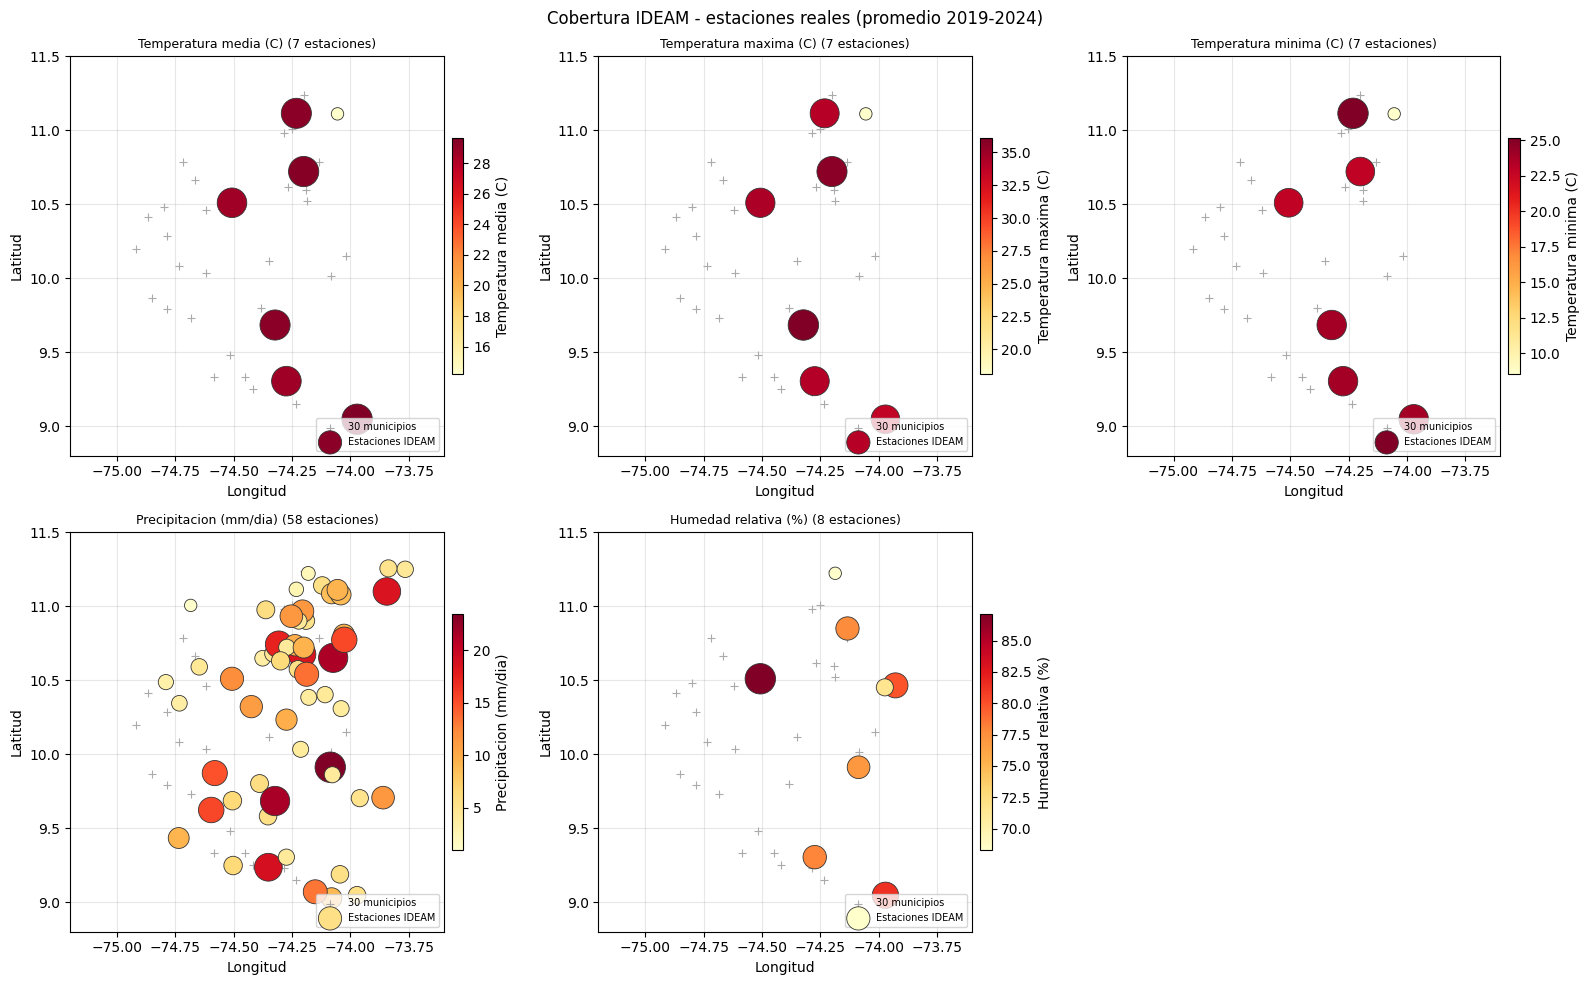

In [5]:
# Mapa de cobertura de estaciones IDEAM por variable
n_vars   = len(VARIABLES_IDEAM)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cobertura IDEAM - estaciones reales (promedio 2019-2024)', fontsize=12)

for idx, ax in enumerate(axes.flat):
    if idx >= n_vars:
        ax.set_visible(False)
        continue
    nombre_var, col_estandar = list(VARIABLES_IDEAM.items())[idx]
    if nombre_var not in ideam_raw:
        ax.set_title(f'{nombre_var}\n(sin datos)', fontsize=8)
        continue

    df  = ideam_raw[nombre_var]
    agg = df.groupby(['id_estacion', 'lat', 'lon'])[col_estandar].mean().reset_index()

    vmin, vmax = agg[col_estandar].min(), agg[col_estandar].max()
    if vmin == vmax:
        vmax = vmin + 1
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    ax.scatter(coords_municipios['lon'], coords_municipios['lat'],
               marker='+', s=40, color='#aaaaaa', linewidths=0.8, zorder=1,
               label='30 municipios')
    sc = ax.scatter(
        agg['lon'], agg['lat'],
        s=norm(agg[col_estandar]) * 400 + 80,
        c=agg[col_estandar], cmap='YlOrRd', norm=norm,
        edgecolors='#333333', linewidths=0.6, zorder=2, label='Estaciones IDEAM',
    )
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label=VARIABLES[col_estandar])
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_title(f"{VARIABLES[col_estandar]} ({agg['id_estacion'].nunique()} estaciones)",
                 fontsize=9)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'ideam_estaciones_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Validacion point-to-pixel

Para cada estacion IDEAM se descarga NASA POWER y ERA5 exactamente en esa coordenada y se calculan RMSE, MAE, R2 y bias entre el valor observado y el estimado por cada reanálisis. Este enfoque es mas riguroso que interpolar el IDEAM porque evalua directamente que tan bien representa cada reanálisis las observaciones reales en tierra.

El proceso es:
- Descargar NASA y ERA5 en las coordenadas exactas de cada estacion IDEAM.
- Alinear las tres series por fecha.
- Calcular RMSE, MAE, R2 y bias por estacion y variable.
- Mapa de burbujas del RMSE por estacion.
- Tabla resumen por variable y fuente.
- Series temporales comparativas en la estacion con mas registros por variable.

In [6]:
# Extraer coordenadas unicas de todas las estaciones IDEAM
filas = []
for nombre_var, df in ideam_raw.items():
    est = df[['id_estacion', 'municipio', 'lat', 'lon']].drop_duplicates('id_estacion')
    filas.append(est)
coords_estaciones = pd.concat(filas).drop_duplicates('id_estacion').reset_index(drop=True)
print(f'Total estaciones unicas: {len(coords_estaciones)}')
coords_estaciones.head(10)

Total estaciones unicas: 63


,id_estacion,municipio,lat,lon
0,25025090,El Banco,9.046333,-73.970833
1,15015050,Santa Marta,11.114694,-74.231028
2,25025300,San Sebastián De Buenavista,9.683667,-74.322278
3,25025002,San Sebastián De Buenavista,9.304056,-74.273639
4,29065000,Pivijai,10.510028,-74.506667
5,29065020,Zona Bananera,10.721111,-74.199722
6,15015060,Santa Marta,11.111083,-74.054694
7,25021600,Plato,9.872500,-74.580389
8,29060350,El Retén,10.631167,-74.298583
9,28040150,Algarrobo,10.308056,-74.039222


In [7]:
# Descargar NASA y ERA5 en las coordenadas exactas de cada estacion
path_nasa_est = DATA_DIR / 'external' / 'nasa_power_estaciones_ideam.parquet'
path_era5_est = DATA_DIR / 'external' / 'era5_estaciones_ideam.parquet'

if path_nasa_est.exists():
    df_nasa_est = pd.read_parquet(path_nasa_est)
    print(f'NASA estaciones cargado desde cache: {df_nasa_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows():
        try:
            df = get_nasa_power_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'  OK {row["id_estacion"]} ({row["municipio"]})')
            time.sleep(0.4)
        except Exception as e:
            print(f'  ERROR {row["id_estacion"]}: {e}')
    df_nasa_est = pd.concat(dfs, ignore_index=True)
    df_nasa_est.to_parquet(path_nasa_est, index=False)

if path_era5_est.exists():
    df_era5_est = pd.read_parquet(path_era5_est)
    print(f'ERA5 estaciones cargado desde cache: {df_era5_est.shape}')
else:
    dfs = []
    for _, row in coords_estaciones.iterrows():
        try:
            df = get_era5_diario(row['lat'], row['lon'])
            df['id_estacion'] = row['id_estacion']
            dfs.append(df)
            print(f'  OK {row["id_estacion"]}')
        except Exception as e:
            print(f'  ERROR {row["id_estacion"]}: {e}')
    df_era5_est = pd.concat(dfs, ignore_index=True)
    df_era5_est.to_parquet(path_era5_est, index=False)

  OK 25025090 (El Banco)
  OK 15015050 (Santa Marta)
  OK 25025300 (San Sebastián De Buenavista)
  OK 25025002 (San Sebastián De Buenavista)
  OK 29065000 (Pivijai)
  OK 29065020 (Zona Bananera)
  OK 15015060 (Santa Marta)
  OK 25021600 (Plato)
  OK 29060350 (El Retén)
  OK 28040150 (Algarrobo)
  OK 15010020 (Santa Marta)
  OK 29060150 (El Retén)
  OK 29060560 (Fundación)
  OK 25021610 (Plato)
  OK 29060030 (El Retén)
  OK 28040320 (Santa Ana)
  OK 29060140 (Zona Bananera)
  OK 29060060 (Aracataca)
  OK 25025000 (Ariguaní (El Dificil))
  OK 29060160 (Zona Bananera)
  OK 29060340 (Ciénaga)
  OK 25021500 (Santa Ana)
  OK 15010310 (Santa Marta)
  OK 29060040 (Fundación)
  OK 29020020 (Pivijai)
  OK 29060170 (El Retén)
  OK 15010300 (Santa Marta)
  OK 28040360 (Ariguaní (El Dificil))
  OK 15010501 (Santa Marta)
  OK 25021620 (Nueva Granada)
  OK 29060180 (Puebloviejo)
  OK 29060200 (Aracataca)
  OK 25021190 (Santa Bárbara De Pinto)
  OK 29060210 (Ciénaga)
  OK 1501500196 (Santa Marta)
  OK

In [8]:
def calcular_metricas(y_obs, y_pred):
    mask = ~(np.isnan(y_obs) | np.isnan(y_pred))
    if mask.sum() < 10:
        return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'Bias': np.nan, 'N': int(mask.sum())}
    yo, yp = y_obs[mask], y_pred[mask]
    rmse   = np.sqrt(mean_squared_error(yo, yp))
    mae    = mean_absolute_error(yo, yp)
    ss_res = np.sum((yo - yp) ** 2)
    ss_tot = np.sum((yo - yo.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    bias   = float(np.mean(yp - yo))
    return {'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
            'R2': round(r2, 4), 'Bias': round(bias, 3), 'N': int(mask.sum())}


rows = []
for nombre_var, col_v in VARIABLES_IDEAM.items():
    if nombre_var not in ideam_raw:
        continue
    df_v = ideam_raw[nombre_var][['id_estacion', 'fecha', col_v, 'lat', 'lon']]

    for id_est in df_v['id_estacion'].unique():
        ideam_s = df_v[df_v['id_estacion'] == id_est].set_index('fecha')
        nasa_s  = df_nasa_est[df_nasa_est['id_estacion'] == id_est].set_index('fecha')
        era5_s  = df_era5_est[df_era5_est['id_estacion'] == id_est].set_index('fecha')
        lat     = float(ideam_s['lat'].iloc[0])
        lon     = float(ideam_s['lon'].iloc[0])

        mn = ideam_s[[col_v]].join(nasa_s[[col_v]], rsuffix='_nasa', how='inner')
        me = ideam_s[[col_v]].join(era5_s[[col_v]], rsuffix='_era5', how='inner')

        met_n = calcular_metricas(mn[col_v].values, mn[f'{col_v}_nasa'].values)
        met_e = calcular_metricas(me[col_v].values, me[f'{col_v}_era5'].values)

        rows.append({'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                     'fuente': 'NASA POWER', **met_n})
        rows.append({'variable': col_v, 'id_estacion': id_est, 'lat': lat, 'lon': lon,
                     'fuente': 'ERA5', **met_e})

df_metricas = pd.DataFrame(rows)
print(f'Metricas calculadas: {len(df_metricas)} filas')
df_metricas.head(10)

Metricas calculadas: 174 filas


,variable,id_estacion,lat,lon,fuente,RMSE,MAE,R2,Bias,N
0,t2m_media,25025090,9.046333,-73.970833,NASA POWER,2.019,1.667,-0.8506,-0.898,1425
1,t2m_media,25025090,9.046333,-73.970833,ERA5,NaN,NaN,NaN,NaN,0
2,t2m_media,15015050,11.114694,-74.231028,NASA POWER,1.895,1.730,-1.4886,-1.705,412
3,t2m_media,15015050,11.114694,-74.231028,ERA5,NaN,NaN,NaN,NaN,0
4,t2m_media,25025300,9.683667,-74.322278,NASA POWER,2.128,1.733,-0.9042,1.251,1005
5,t2m_media,25025300,9.683667,-74.322278,ERA5,NaN,NaN,NaN,NaN,0
6,t2m_media,25025002,9.304056,-74.273639,NASA POWER,2.276,1.856,-1.3237,1.407,1920
7,t2m_media,25025002,9.304056,-74.273639,ERA5,NaN,NaN,NaN,NaN,0
8,t2m_media,29065000,10.510028,-74.506667,NASA POWER,1.309,1.071,-0.6196,0.152,1918
9,t2m_media,29065000,10.510028,-74.506667,ERA5,NaN,NaN,NaN,NaN,0


In [9]:
# Tabla resumen por variable y fuente
resumen = (
    df_metricas
    .groupby(['variable', 'fuente'])
    .agg(RMSE_media=('RMSE', 'mean'), MAE_media=('MAE', 'mean'),
         R2_media=('R2', 'mean'), Bias_medio=('Bias', 'mean'),
         N_estaciones=('id_estacion', 'count'))
    .round(3).reset_index()
)
resumen['Variable'] = resumen['variable'].map(VARIABLES)
print('Comparacion NASA POWER vs ERA5 contra observaciones IDEAM:')
resumen[['Variable', 'fuente', 'RMSE_media', 'MAE_media', 'R2_media', 'Bias_medio', 'N_estaciones']]

Comparacion NASA POWER vs ERA5 contra observaciones IDEAM:


,Variable,fuente,RMSE_media,MAE_media,R2_media,Bias_medio,N_estaciones
0,Humedad relativa (%),ERA5,NaN,NaN,NaN,NaN,8
1,Humedad relativa (%),NASA POWER,15.748,13.201,-2.185,-8.025,8
2,Precipitacion (mm/dia),ERA5,NaN,NaN,NaN,NaN,58
3,Precipitacion (mm/dia),NASA POWER,17.659,8.957,-0.304,-5.728,58
4,Temperatura maxima (C),ERA5,NaN,NaN,NaN,NaN,7
5,Temperatura maxima (C),NASA POWER,3.790,3.350,-7.470,1.064,7
6,Temperatura media (C),ERA5,NaN,NaN,NaN,NaN,7
7,Temperatura media (C),NASA POWER,2.819,2.537,-9.873,1.132,7
8,Temperatura minima (C),ERA5,NaN,NaN,NaN,NaN,7
9,Temperatura minima (C),NASA POWER,3.327,3.001,-8.655,2.718,7


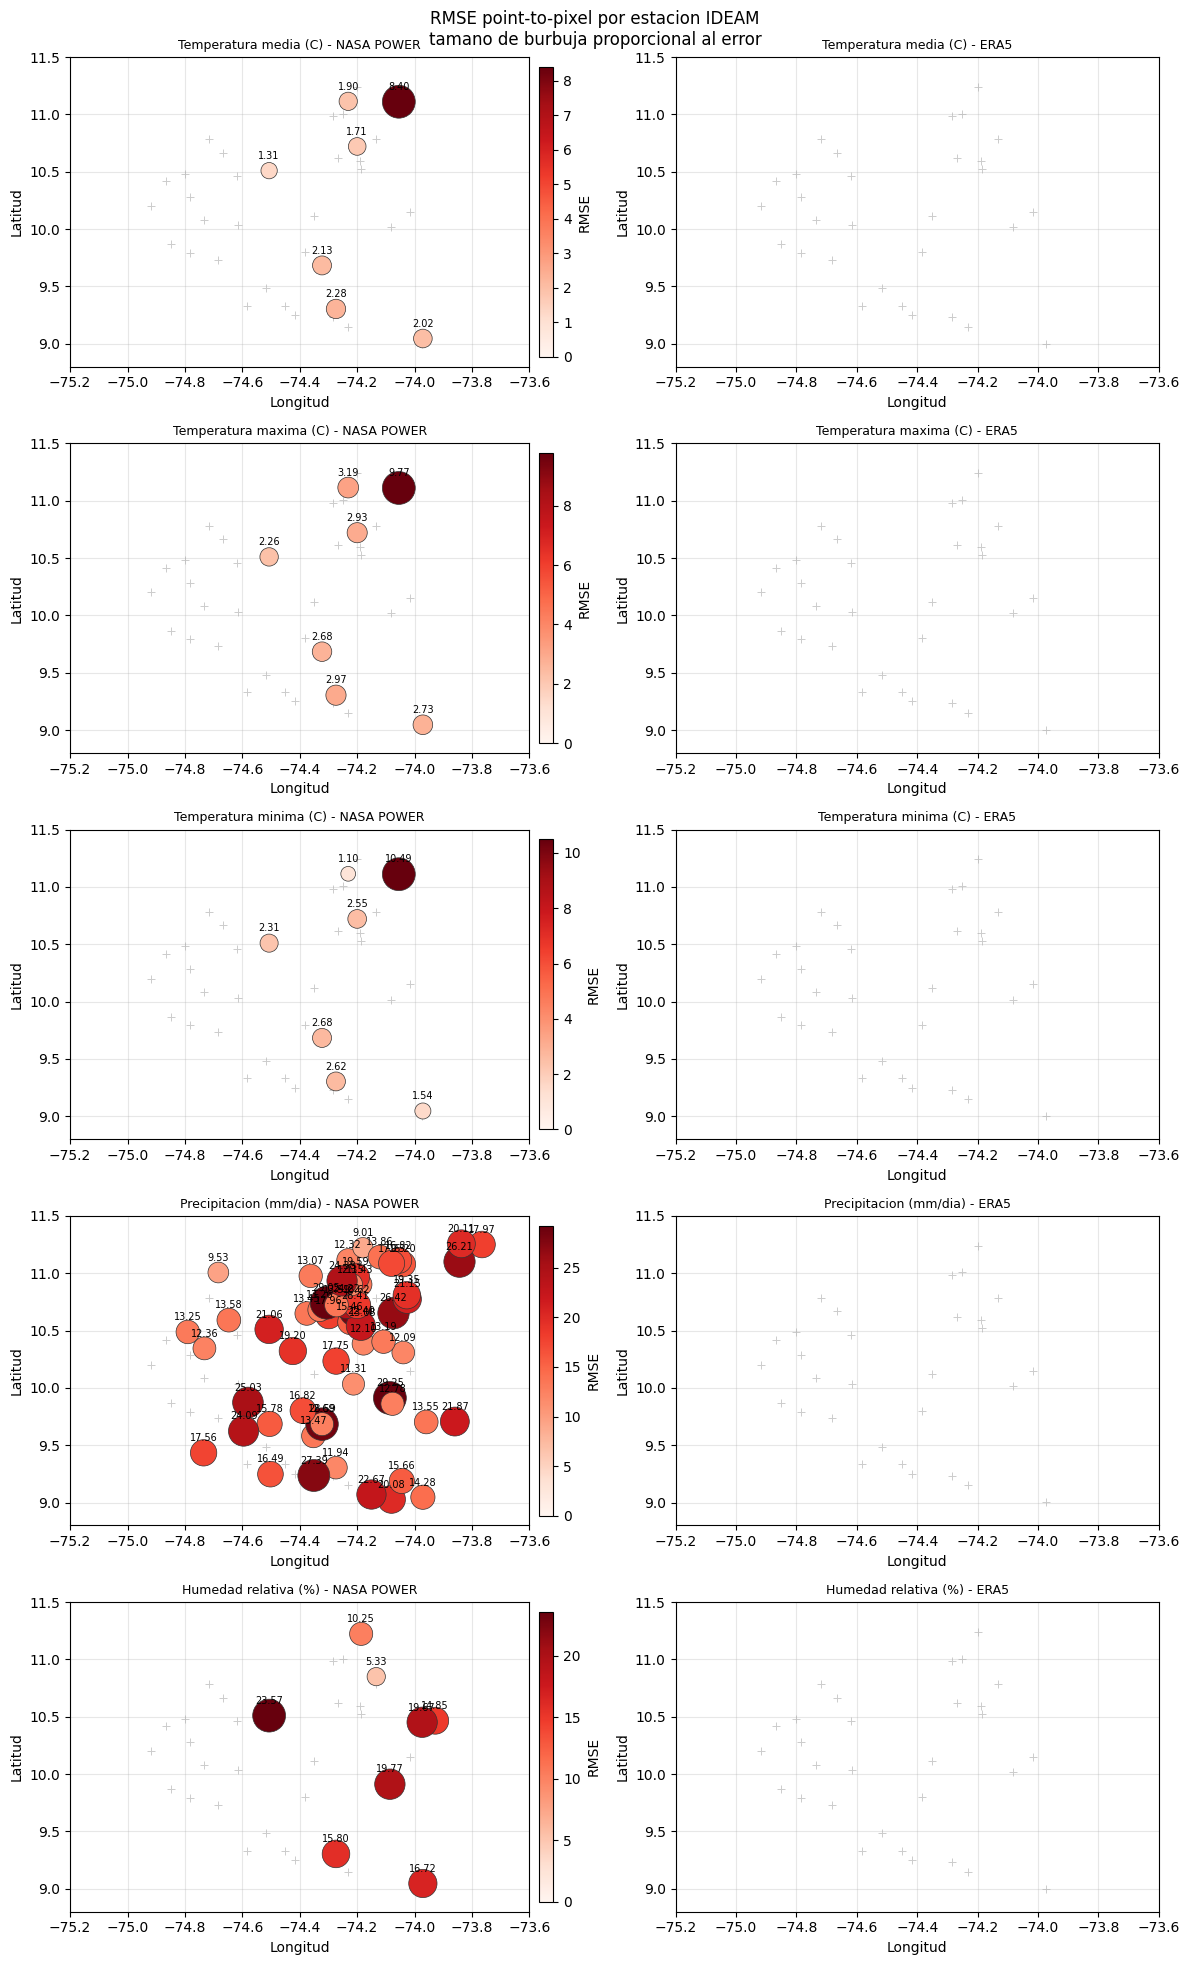

In [10]:
# Mapa de RMSE por estacion - una fila por variable, dos columnas por fuente
vars_list = list(VARIABLES_IDEAM.values())
fig, axes = plt.subplots(len(vars_list), 2, figsize=(12, 4 * len(vars_list)))
fig.suptitle('RMSE point-to-pixel por estacion IDEAM\ntamano de burbuja proporcional al error',
             fontsize=12)

for i, col_v in enumerate(vars_list):
    for j, fuente in enumerate(['NASA POWER', 'ERA5']):
        ax  = axes[i, j]
        sub = df_metricas[(df_metricas['variable'] == col_v) &
                          (df_metricas['fuente'] == fuente)].dropna(subset=['RMSE'])

        ax.scatter(coords_municipios['lon'], coords_municipios['lat'],
                   marker='+', s=30, color='#cccccc', linewidths=0.7, zorder=1)

        if len(sub) > 0:
            vmax_r = sub['RMSE'].max()
            norm   = mcolors.Normalize(vmin=0, vmax=vmax_r if vmax_r > 0 else 1)
            sc = ax.scatter(
                sub['lon'], sub['lat'],
                s=norm(sub['RMSE']) * 500 + 60,
                c=sub['RMSE'], cmap='Reds', norm=norm,
                edgecolors='#333333', linewidths=0.5, zorder=2,
            )
            plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label='RMSE')
            for _, row in sub.iterrows():
                ax.annotate(f"{row['RMSE']:.2f}", (row['lon'], row['lat']),
                            fontsize=7, ha='center', va='bottom',
                            xytext=(0, 7), textcoords='offset points')

        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)
        ax.set_title(f'{VARIABLES[col_v]} - {fuente}', fontsize=9)
        ax.set_xlabel('Longitud')
        ax.set_ylabel('Latitud')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'validacion_point_to_pixel_rmse.png',
            dpi=150, bbox_inches='tight')
plt.show()

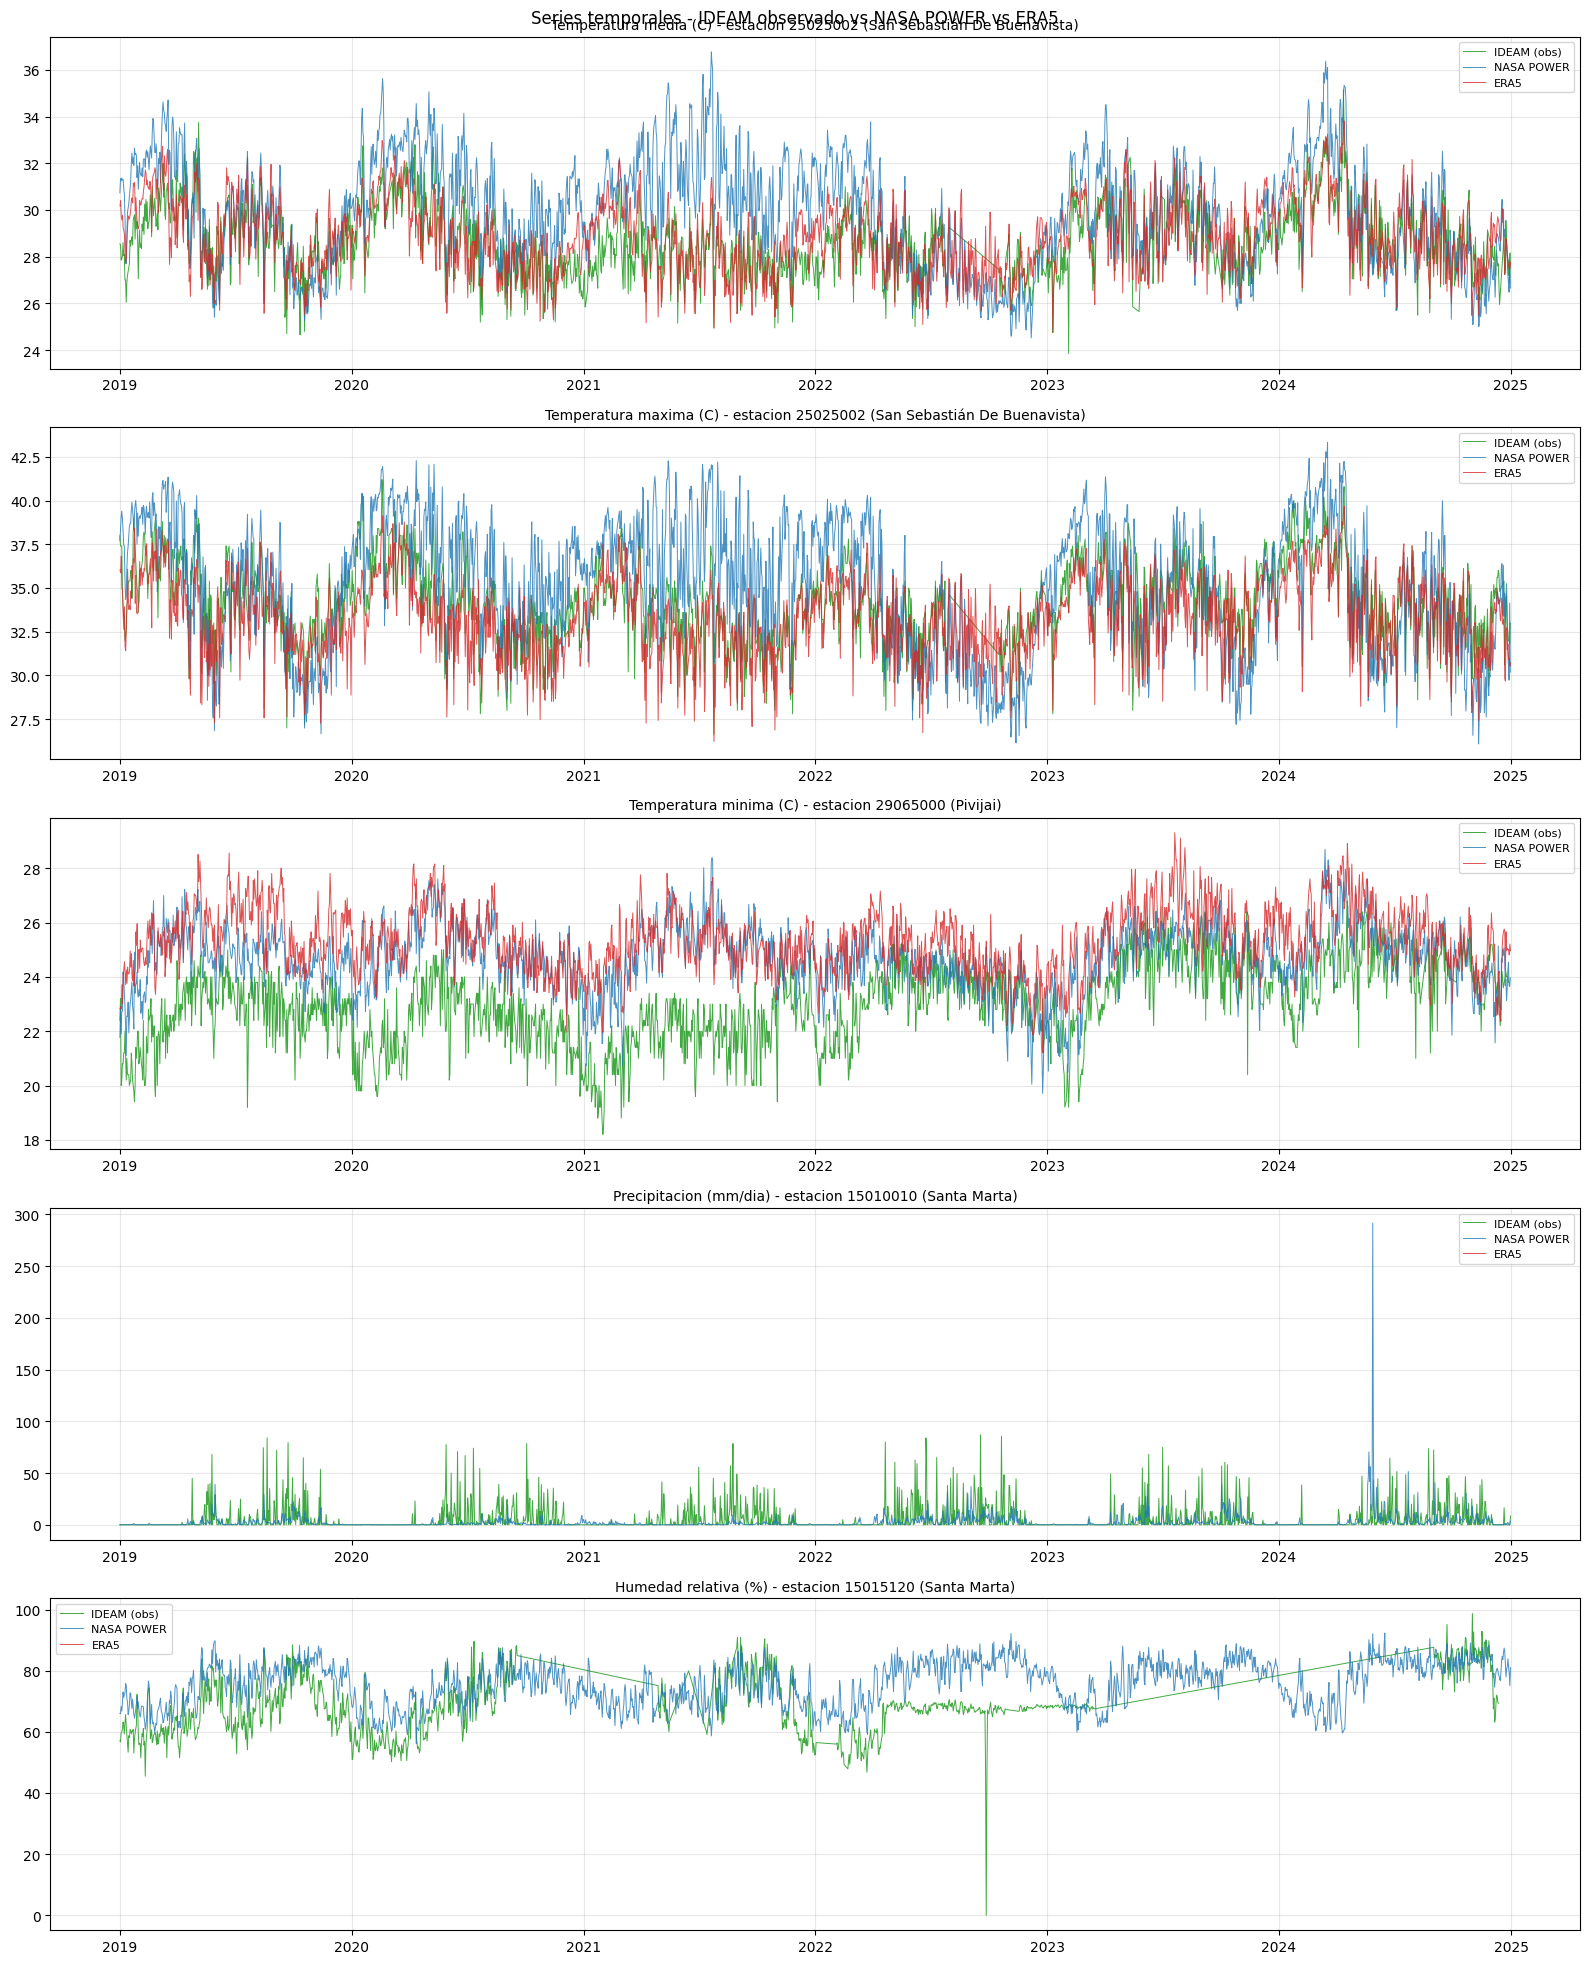

In [11]:
# Series temporales comparativas - estacion con mas registros por variable
fig, axes = plt.subplots(len(vars_list), 1, figsize=(16, 4 * len(vars_list)))
fig.suptitle('Series temporales - IDEAM observado vs NASA POWER vs ERA5', fontsize=12)

for ax, (nombre_var, col_v) in zip(axes, VARIABLES_IDEAM.items()):
    if nombre_var not in ideam_raw:
        ax.set_visible(False)
        continue
    df_v   = ideam_raw[nombre_var]
    id_ref = df_v.groupby('id_estacion')[col_v].count().idxmax()
    mun_r  = df_v[df_v['id_estacion'] == id_ref]['municipio'].iloc[0]

    ideam_s = df_v[df_v['id_estacion'] == id_ref].set_index('fecha')[col_v]
    nasa_s  = df_nasa_est[df_nasa_est['id_estacion'] == id_ref].set_index('fecha')[col_v]
    era5_s  = df_era5_est[df_era5_est['id_estacion'] == id_ref].set_index('fecha')[col_v]

    ax.plot(ideam_s.index, ideam_s.values, label='IDEAM (obs)',
            color='#2ca02c', linewidth=0.7, alpha=0.9)
    ax.plot(nasa_s.index,  nasa_s.values,  label='NASA POWER',
            color='#1f77b4', linewidth=0.7, alpha=0.8)
    ax.plot(era5_s.index,  era5_s.values,  label='ERA5',
            color='#d62728', linewidth=0.7, alpha=0.8)
    ax.set_title(f'{VARIABLES[col_v]} - estacion {id_ref} ({mun_r})', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'series_temporales_validacion.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 6. Analisis geoestadestico (scikit-gstat)

Antes de interpolar con Kriging se analiza la estructura espacial de cada variable IDEAM. El objetivo es seleccionar el modelo de variograma que mejor describe como cambia la similitud entre estaciones con la distancia.

El variograma empirico se construye tomando todos los pares de estaciones disponibles, calculando la diferencia al cuadrado de sus valores y graficandola contra la distancia. Se ajustan cuatro modelos (spherical, exponential, gaussian, matern) y se selecciona el de menor RMSE de ajuste. Adicionalmente se realiza analisis de anisotropia direccional para verificar si la variable se comporta igual en todas las direcciones, y cross-validation leave-one-out para estimar el error de prediccion de la interpolacion.

Nota sobre humedad relativa: con 8 estaciones el variograma tendra pocos pares de distancia y el ajuste sera mas incierto. Los resultados de LOO para esta variable deben interpretarse con cautela.

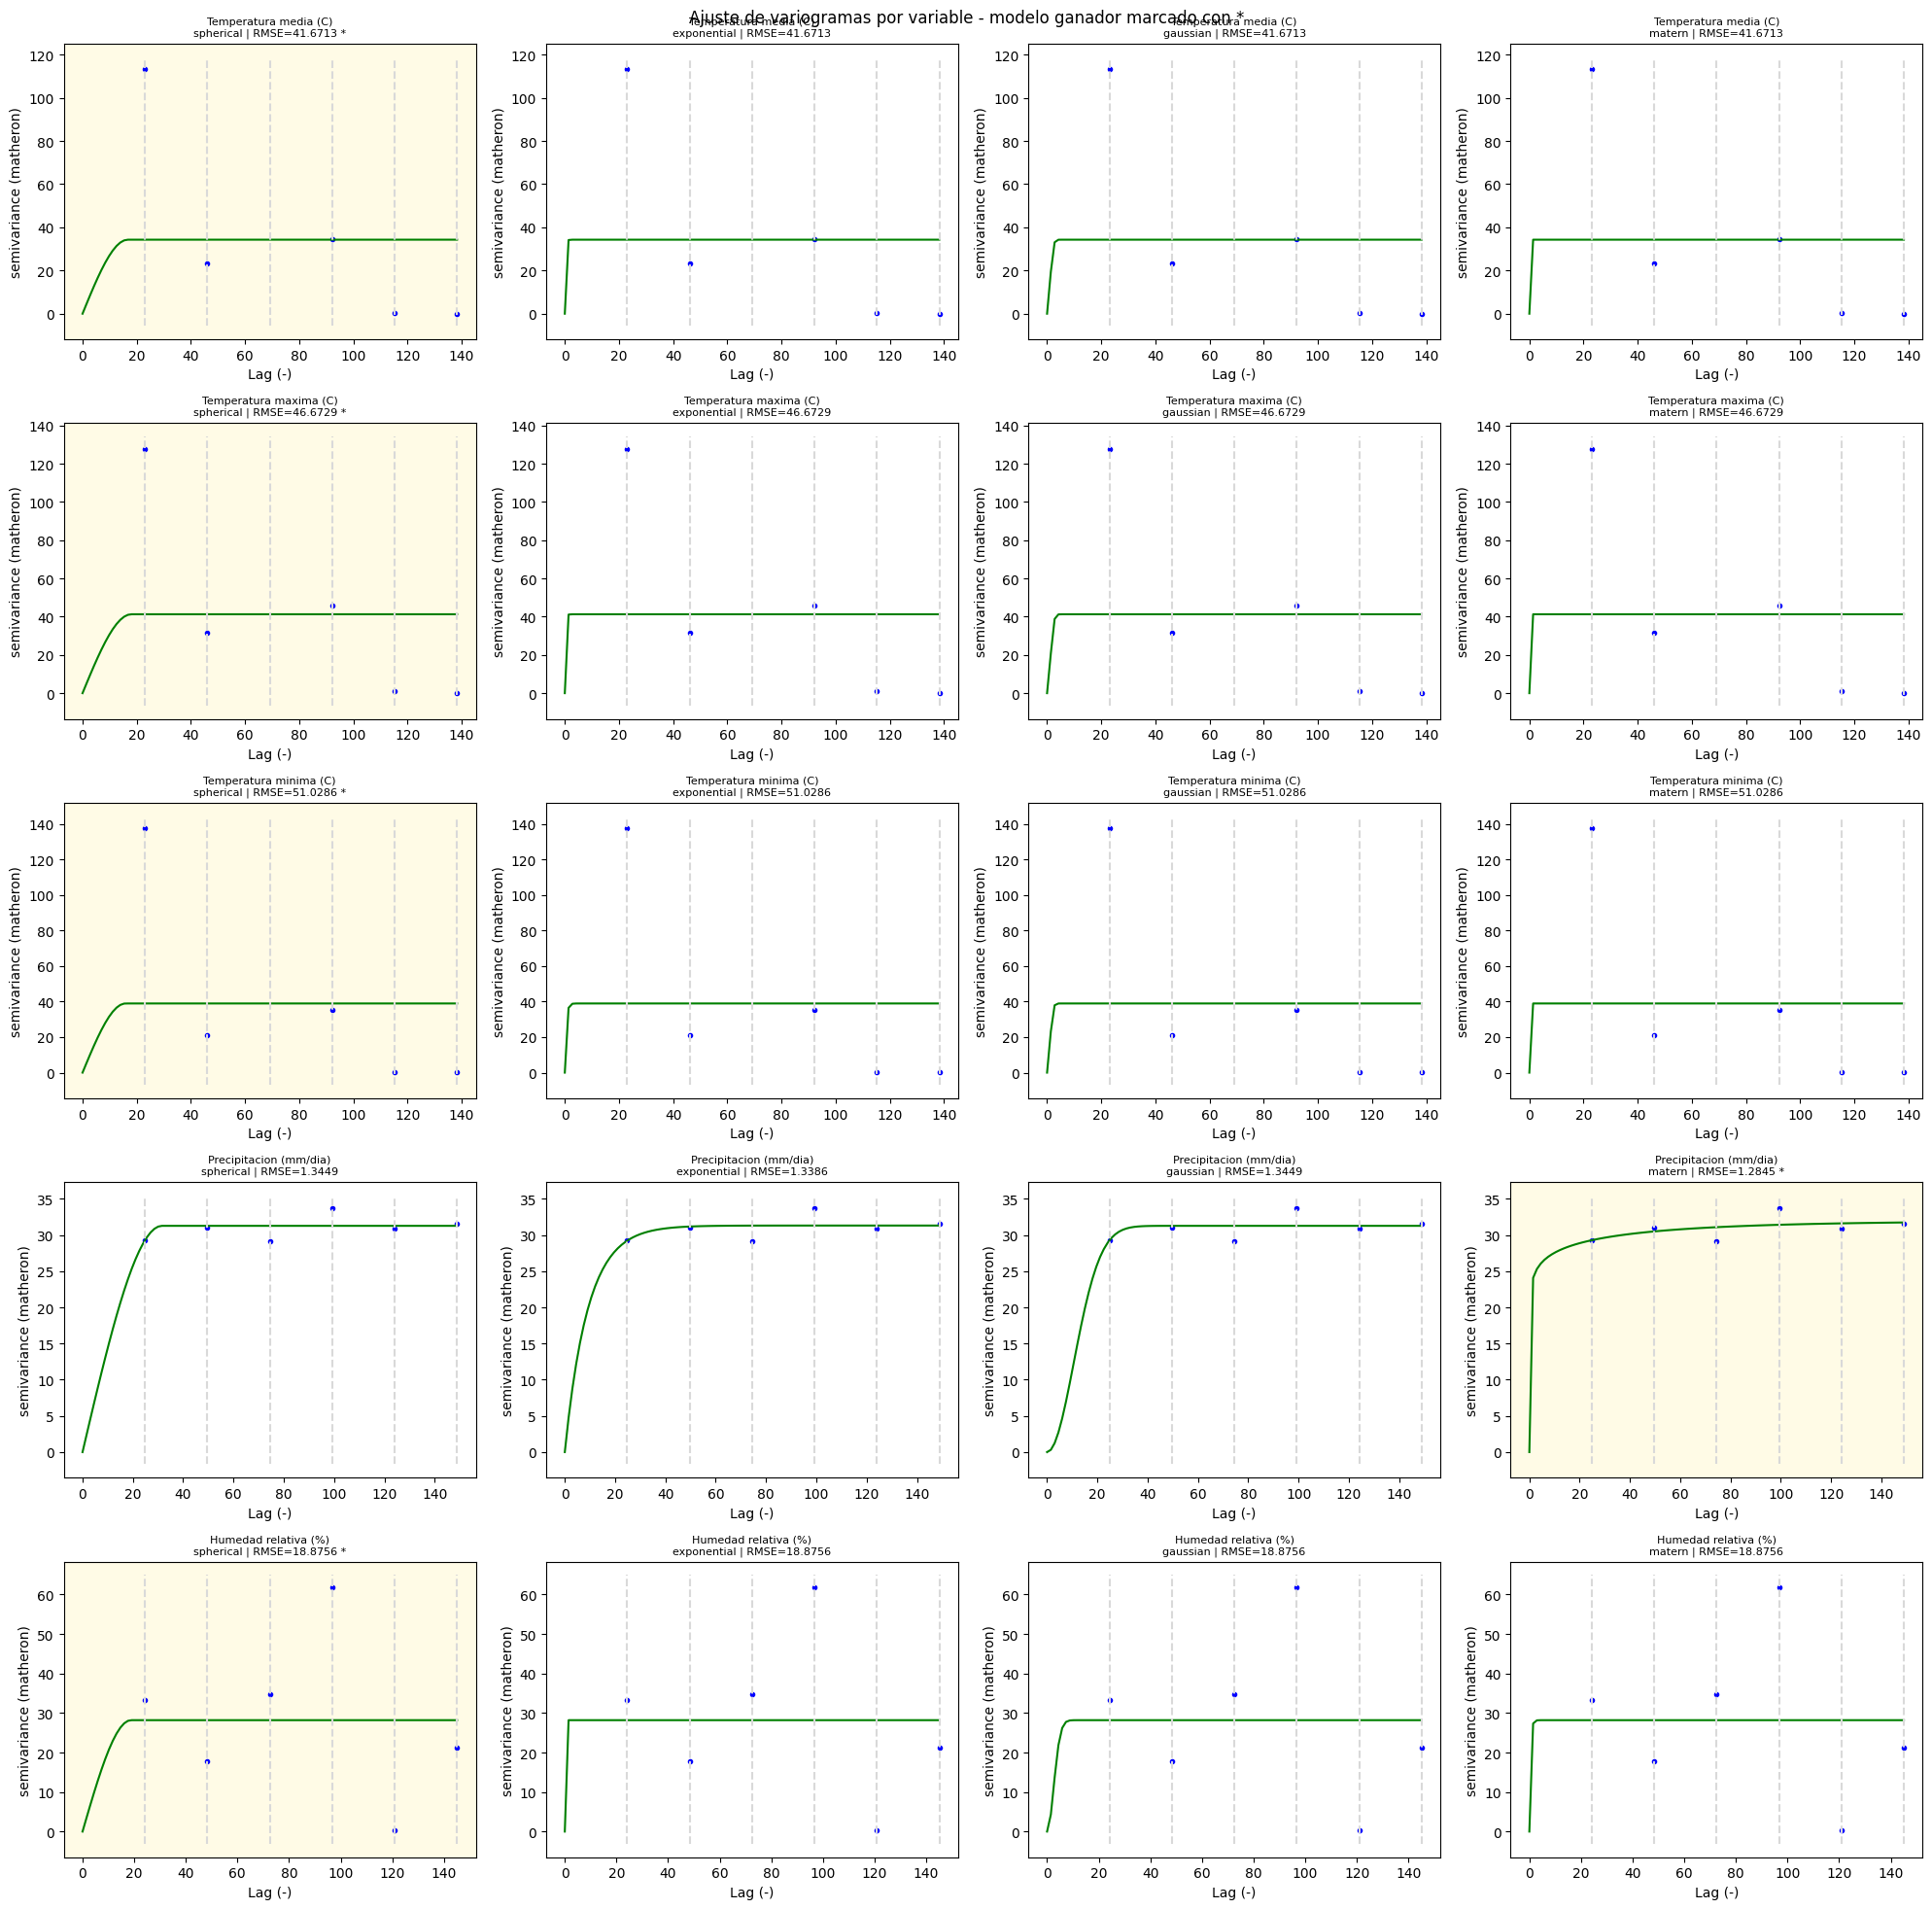


Modelos ganadores por variable:
  temperatura_media      -> spherical
  temperatura_maxima     -> spherical
  temperatura_minima     -> spherical
  precipitacion          -> matern
  humedad_relativa       -> spherical


In [12]:
MODELOS_VARIOGRAMA = ['spherical', 'exponential', 'gaussian', 'matern']

def construir_dataset_espacial(nombre_var):
    col_v = VARIABLES_IDEAM[nombre_var]
    df    = ideam_raw[nombre_var]
    agg   = (df.groupby(['id_estacion', 'lat', 'lon'])[col_v]
               .mean().reset_index().dropna())
    # Proyeccion aproximada a km para el variograma
    lat0 = agg['lat'].mean()
    lon0 = agg['lon'].mean()
    agg['x_km'] = (agg['lon'] - lon0) * 111.32 * np.cos(np.radians(lat0))
    agg['y_km'] = (agg['lat'] - lat0) * 110.57
    return agg[['x_km', 'y_km']].values, agg[col_v].values, agg


modelos_ganadores = {}
fig, axes = plt.subplots(n_vars, len(MODELOS_VARIOGRAMA),
                          figsize=(5 * len(MODELOS_VARIOGRAMA), 4 * n_vars))
fig.suptitle('Ajuste de variogramas por variable - modelo ganador marcado con *', fontsize=12)

for i, (nombre_var, col_v) in enumerate(VARIABLES_IDEAM.items()):
    if nombre_var not in ideam_raw:
        for j in range(len(MODELOS_VARIOGRAMA)):
            axes[i, j].set_visible(False)
        continue

    coords, valores, _ = construir_dataset_espacial(nombre_var)
    resultados = {}
    for modelo in MODELOS_VARIOGRAMA:
        try:
            V = skg.Variogram(coords, valores, model=modelo, n_lags=6, maxlag=0.6)
            resultados[modelo] = {'V': V, 'rmse': V.rmse}
        except Exception as e:
            resultados[modelo] = {'V': None, 'rmse': np.inf}

    mejor = min(resultados, key=lambda m: resultados[m]['rmse'])
    modelos_ganadores[nombre_var] = mejor

    for j, modelo in enumerate(MODELOS_VARIOGRAMA):
        ax  = axes[i, j]
        res = resultados[modelo]
        if res['V'] is None:
            ax.set_title(f'{modelo}\n(error)', fontsize=8)
            continue
        try:
            res['V'].plot(axes=ax, show=False)
        except Exception:
            pass
        titulo = f"{VARIABLES[col_v][:22]}\n{modelo} | RMSE={res['rmse']:.4f}"
        if modelo == mejor:
            titulo += ' *'
            ax.set_facecolor('#fffbe6')
        ax.set_title(titulo, fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'variogramas_ajuste_modelos.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nModelos ganadores por variable:')
for var, modelo in modelos_ganadores.items():
    print(f'  {var:22} -> {modelo}')

In [13]:
# Cross-validation leave-one-out
print('Cross-validation leave-one-out:\n')
cv_resultados = {}

for nombre_var in VARIABLES_IDEAM:
    if nombre_var not in ideam_raw or nombre_var not in modelos_ganadores:
        continue
    coords, valores, _ = construir_dataset_espacial(nombre_var)
    if len(coords) < 3:
        print(f'  {nombre_var}: {len(coords)} estaciones, LOO no aplicable')
        continue
    try:
        modelo = modelos_ganadores[nombre_var]
        V      = skg.Variogram(coords, valores, model=modelo, n_lags=6, maxlag=0.6)
        cv     = skg.cross_validate(V, cv_method='loo')
        rmse_loo = np.sqrt(np.mean((cv['true'] - cv['predicted']) ** 2))
        mae_loo  = np.mean(np.abs(cv['true'] - cv['predicted']))
        cv_resultados[nombre_var] = {'modelo': modelo, 'RMSE_LOO': round(rmse_loo, 4),
                                      'MAE_LOO': round(mae_loo, 4)}
        print(f'  {nombre_var:22} modelo={modelo:12} RMSE_LOO={rmse_loo:.4f}  MAE_LOO={mae_loo:.4f}')
    except Exception as e:
        print(f'  {nombre_var}: error en LOO - {e}')

Cross-validation leave-one-out:

  temperatura_media: error en LOO - module 'skgstat' has no attribute 'cross_validate'
  temperatura_maxima: error en LOO - module 'skgstat' has no attribute 'cross_validate'
  temperatura_minima: error en LOO - module 'skgstat' has no attribute 'cross_validate'
  precipitacion: error en LOO - module 'skgstat' has no attribute 'cross_validate'
  humedad_relativa: error en LOO - module 'skgstat' has no attribute 'cross_validate'


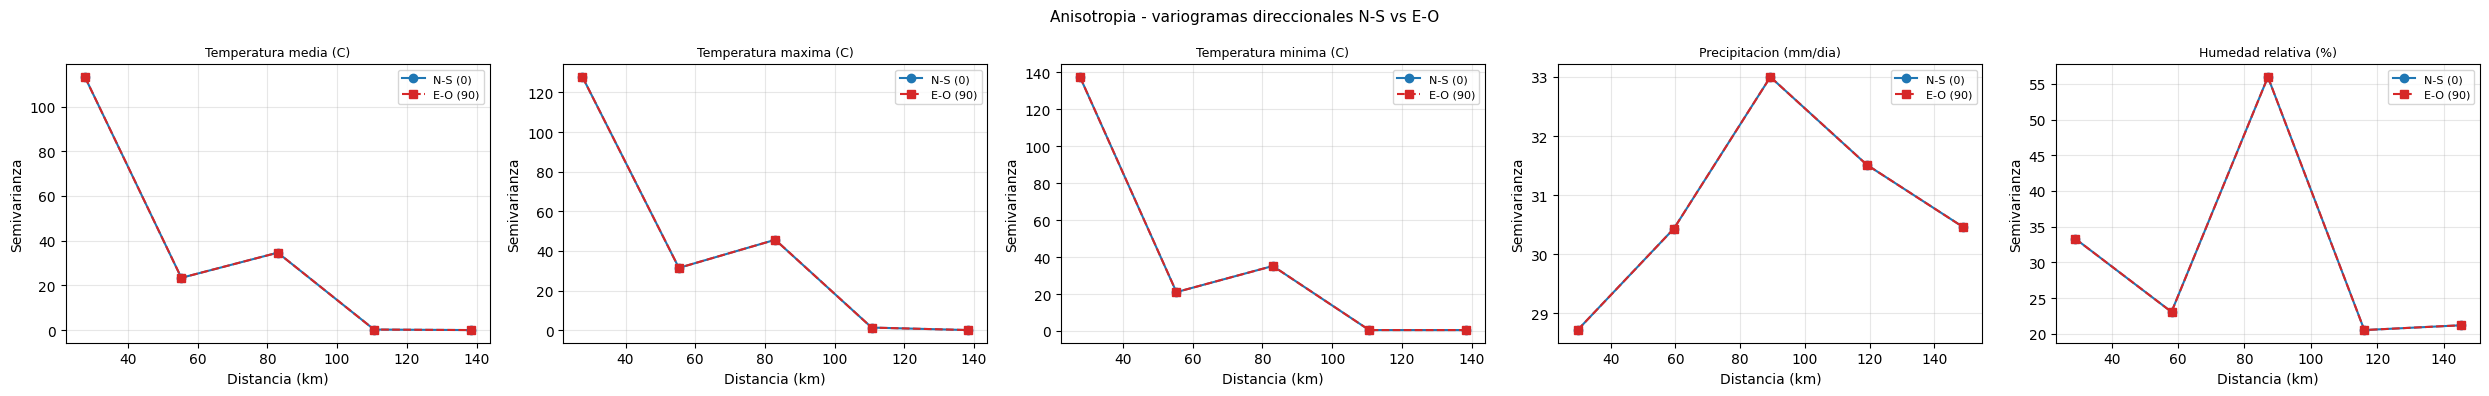

In [14]:
# Analisis de anisotropia - variogramas direccionales N-S vs E-O
fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4))
fig.suptitle('Anisotropia - variogramas direccionales N-S vs E-O', fontsize=11)

for ax, (nombre_var, col_v) in zip(axes, VARIABLES_IDEAM.items()):
    if nombre_var not in ideam_raw:
        ax.set_visible(False)
        continue
    coords, valores, _ = construir_dataset_espacial(nombre_var)
    if len(coords) < 3:
        ax.set_title(f'{VARIABLES[col_v][:20]}\n(pocas estaciones)', fontsize=8)
        continue
    try:
        V_ns = skg.Variogram(coords, valores, azimuth=0,  tolerance=45, n_lags=5, maxlag=0.6)
        V_eo = skg.Variogram(coords, valores, azimuth=90, tolerance=45, n_lags=5, maxlag=0.6)
        ax.plot(V_ns.bins, V_ns.experimental, 'o-',  label='N-S (0)',   color='#1f77b4')
        ax.plot(V_eo.bins, V_eo.experimental, 's--', label='E-O (90)', color='#d62728')
        ax.set_title(VARIABLES[col_v][:22], fontsize=9)
        ax.set_xlabel('Distancia (km)')
        ax.set_ylabel('Semivarianza')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    except Exception as e:
        ax.set_title(f'{VARIABLES[col_v][:20]}\n({e})', fontsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'variogramas_anisotropia.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 7. Interpolacion Kriging Ordinario (PyKrige)

Con el modelo de variograma seleccionado en la seccion anterior se interpola cada variable IDEAM hacia los 30 municipios del Magdalena. Kriging Ordinario asume media constante y desconocida en el area de estudio, lo que es apropiado para el Magdalena dado que no hay un gradiente altitudinal significativo entre los municipios de interes — la mayoria se encuentran en la llanura costera y el valle del rio Magdalena.

PyKrige entrega dos arrays por cada punto estimado: el valor interpolado y la varianza del error de prediccion. Municipios cercanos a estaciones tendra varianza baja; municipios alejados de todas las estaciones tendra varianza alta. Ese mapa de varianza es la medida de confianza de la interpolacion y debe reportarse junto a los valores estimados.

In [15]:
lats_d    = np.array([MUNICIPIOS[m]['lat'] for m in MUNICIPIOS])
lons_d    = np.array([MUNICIPIOS[m]['lon'] for m in MUNICIPIOS])
nombres_d = list(MUNICIPIOS.keys())


def interpolar_kriging_diario(nombre_var):
    col_v  = VARIABLES_IDEAM[nombre_var]
    modelo = modelos_ganadores.get(nombre_var, 'spherical')
    df     = ideam_raw[nombre_var][['id_estacion', 'fecha', col_v, 'lat', 'lon']]
    df     = df.dropna(subset=[col_v, 'lat', 'lon'])

    resultados    = []
    fechas_unicas = df['fecha'].drop_duplicates().sort_values()

    for fecha in fechas_unicas:
        sub = (df[df['fecha'] == fecha]
               .groupby(['id_estacion', 'lat', 'lon'], as_index=False)[col_v].mean())
        if len(sub) < 2:
            continue
        try:
            ok = OrdinaryKriging(
                sub['lon'].values, sub['lat'].values, sub[col_v].values,
                variogram_model=modelo, verbose=False, enable_plotting=False,
            )
            z, ss = ok.execute('points', lons_d, lats_d)
        except Exception:
            z  = np.full(len(lats_d), np.nan)
            ss = np.full(len(lats_d), np.nan)

        for i, mun in enumerate(nombres_d):
            resultados.append({
                'fecha':       fecha,
                'municipio':   mun,
                col_v:         float(z[i]),
                f'{col_v}_var': float(ss[i]),
            })
    return pd.DataFrame(resultados)


print('Interpolando con Kriging Ordinario...\n')
ideam_kriging = {}
for nombre_var in VARIABLES_IDEAM:
    if nombre_var not in ideam_raw or nombre_var not in modelos_ganadores:
        print(f'  {nombre_var}: omitida')
        continue
    print(f'  {nombre_var} (modelo: {modelos_ganadores[nombre_var]})...')
    ideam_kriging[nombre_var] = interpolar_kriging_diario(nombre_var)
    print(f'    -> {len(ideam_kriging[nombre_var]):,} filas')

Interpolando con Kriging Ordinario...

  temperatura_media (modelo: spherical)...
    -> 62,580 filas
  temperatura_maxima (modelo: spherical)...
    -> 64,140 filas
  temperatura_minima (modelo: spherical)...
    -> 64,260 filas
  precipitacion (modelo: matern)...
    -> 65,760 filas
  humedad_relativa (modelo: spherical)...
    -> 44,640 filas


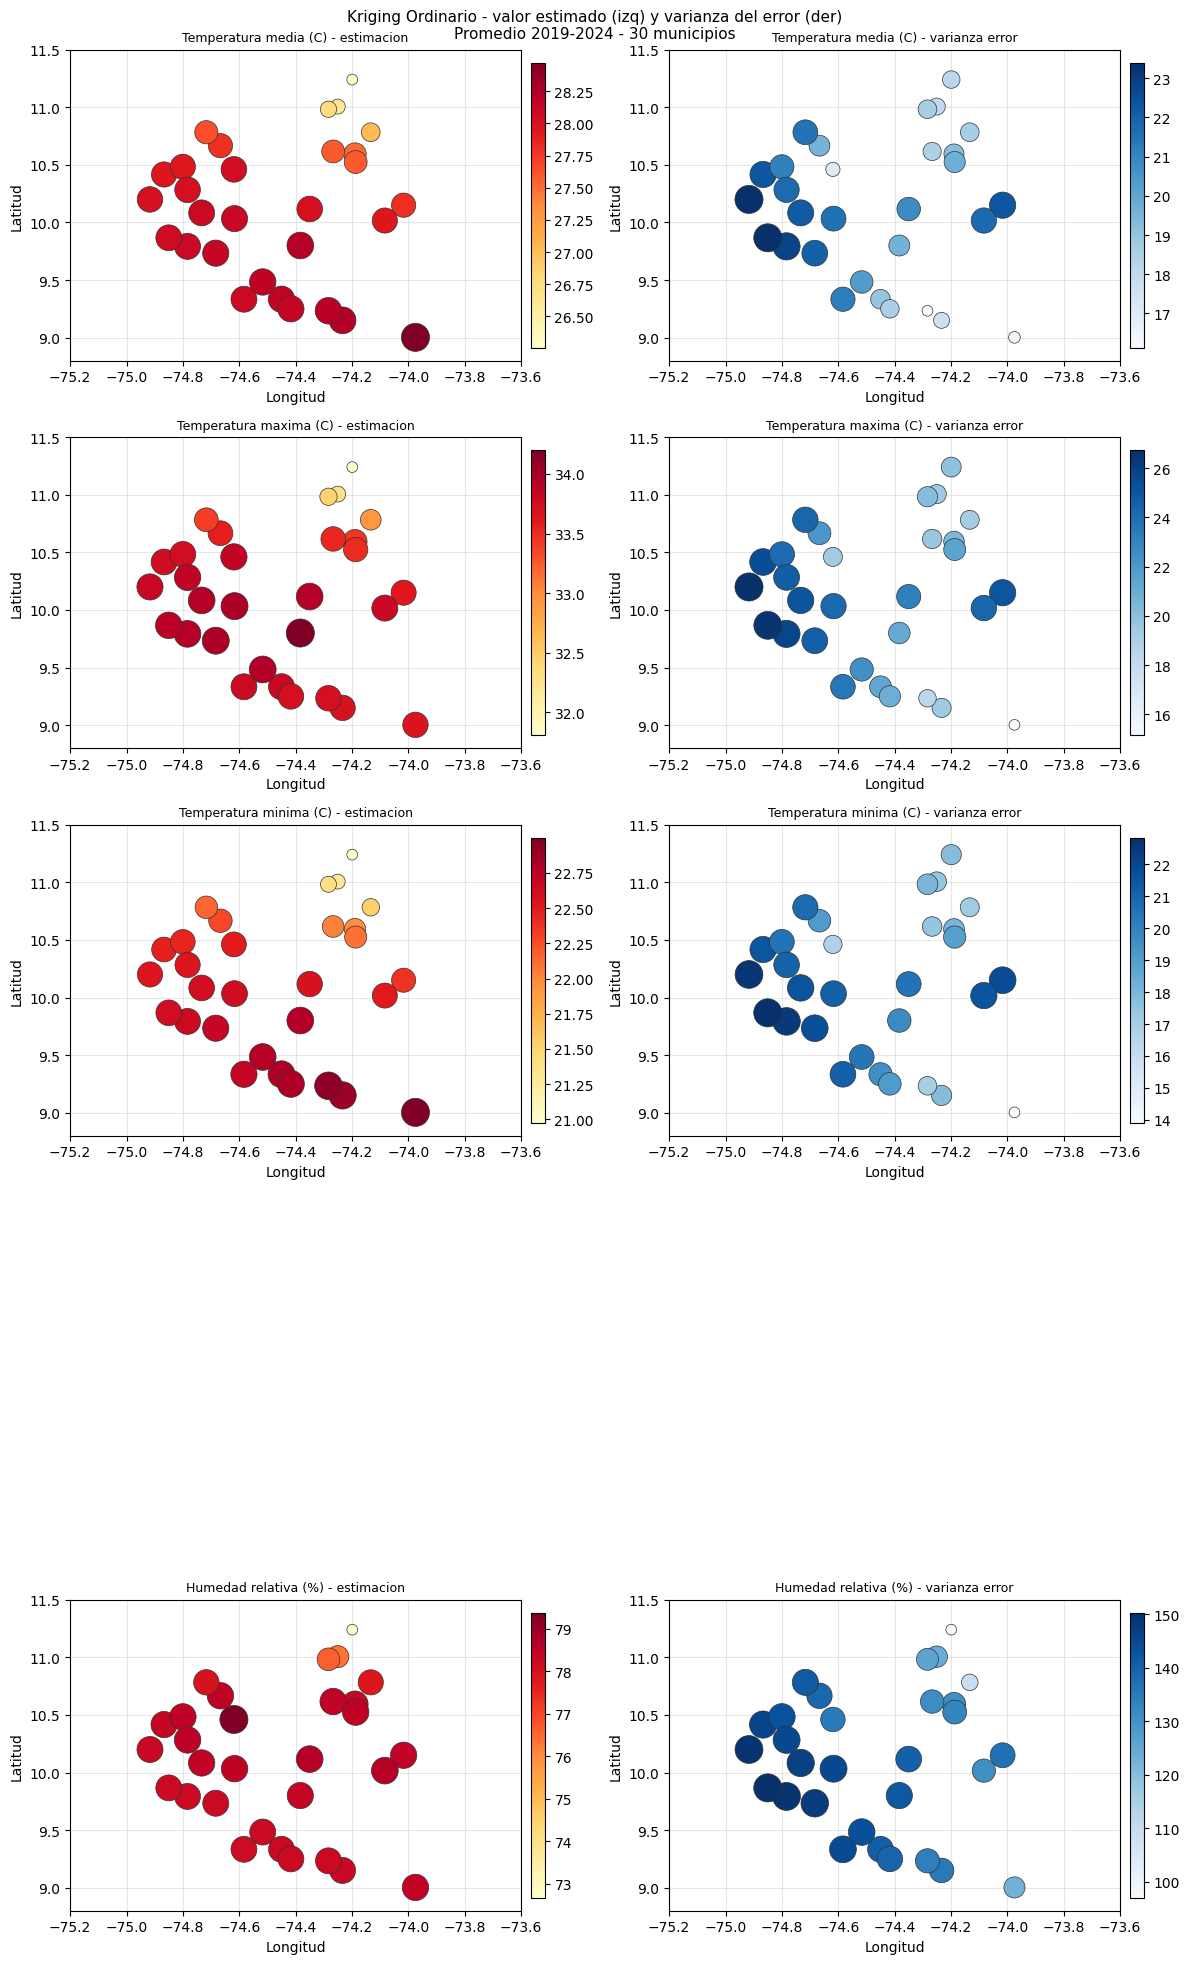

In [16]:
# Mapa de valor interpolado y varianza del error - promedio del periodo
fig, axes = plt.subplots(n_vars, 2, figsize=(12, 4 * n_vars))
fig.suptitle('Kriging Ordinario - valor estimado (izq) y varianza del error (der)\n'
             'Promedio 2019-2024 - 30 municipios', fontsize=11)

for i, (nombre_var, col_v) in enumerate(VARIABLES_IDEAM.items()):
    ax_val = axes[i, 0]
    ax_var = axes[i, 1]

    if nombre_var not in ideam_kriging:
        ax_val.set_visible(False)
        ax_var.set_visible(False)
        continue

    df_k = ideam_kriging[nombre_var]
    agg  = (df_k.groupby('municipio')[[col_v, f'{col_v}_var']]
              .mean().reset_index().merge(coords_municipios, on='municipio'))

    for ax, col_plot, cmap, titulo_suf in [
        (ax_val, col_v,           'YlOrRd', 'estimacion'),
        (ax_var, f'{col_v}_var',  'Blues',  'varianza error'),
    ]:
        sub = agg.dropna(subset=[col_plot])
        if sub.empty:
            ax.set_visible(False)
            continue
        vmin, vmax = sub[col_plot].min(), sub[col_plot].max()
        if vmin == vmax:
            vmax = vmin + 1
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        sc = ax.scatter(
            sub['lon'], sub['lat'],
            s=norm(sub[col_plot]) * 350 + 60,
            c=sub[col_plot], cmap=cmap, norm=norm,
            edgecolors='#333333', linewidths=0.5, zorder=2,
        )
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)
        ax.set_title(f'{VARIABLES[col_v][:25]} - {titulo_suf}', fontsize=9)
        ax.set_xlabel('Longitud')
        ax.set_ylabel('Latitud')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'kriging_estimacion_y_varianza.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 8. Dataset consolidado - agregacion semanal

Se consolidan las tres fuentes a semana epidemiologica (Sunday-start, convencion OPS/SIVIGILA). El dataset final tiene una fila por (municipio, año_epi, semana_epi). Las columnas llevan sufijo _nasa, _era5 o _ideam para que el modelo SARIMAX pueda seleccionar o combinar las fuentes. Los municipios sin cobertura IDEAM tendran NaN en las columnas _ideam.

In [17]:
def agregar_semanal(df, col_vars, col_suma=None):
    df       = df.copy()
    fecha_aj = pd.to_datetime(df['fecha']) + pd.Timedelta(days=1)
    df['año_epi']    = fecha_aj.dt.isocalendar().year.astype(int)
    df['semana_epi'] = fecha_aj.dt.isocalendar().week.astype(int)
    agg_dict = {}
    for col in col_vars:
        if col not in df.columns:
            continue
        agg_dict[col] = (col, 'sum') if col_suma and col in col_suma else (col, 'mean')
    return df.groupby(['municipio', 'año_epi', 'semana_epi']).agg(**agg_dict).reset_index()


cols_clima = list(VARIABLES.keys())

df_nasa_sem = agregar_semanal(df_nasa_diario, cols_clima, col_suma=['precipitacion'])
df_nasa_sem = df_nasa_sem.rename(columns={c: f'{c}_nasa' for c in cols_clima})

df_era5_sem = agregar_semanal(df_era5_diario, cols_clima, col_suma=['precipitacion'])
df_era5_sem = df_era5_sem.rename(columns={c: f'{c}_era5' for c in cols_clima})

dfs_ideam_sem = []
for nombre_var, col_v in VARIABLES_IDEAM.items():
    if nombre_var not in ideam_kriging:
        continue
    df_k     = ideam_kriging[nombre_var].copy()
    col_suma = [col_v] if nombre_var == 'precipitacion' else None
    df_k_sem = agregar_semanal(df_k, [col_v, f'{col_v}_var'], col_suma=col_suma)
    df_k_sem = df_k_sem.rename(columns={
        col_v:           f'{col_v}_ideam',
        f'{col_v}_var':  f'{col_v}_ideam_var',
    })
    dfs_ideam_sem.append(df_k_sem)

df_clima = df_nasa_sem.merge(df_era5_sem, on=['municipio', 'año_epi', 'semana_epi'], how='outer')
for df_k_sem in dfs_ideam_sem:
    df_clima = df_clima.merge(df_k_sem, on=['municipio', 'año_epi', 'semana_epi'], how='left')

print(f'Dataset climatico consolidado:')
print(f'  Shape: {df_clima.shape}')
print(f'  Municipios: {df_clima["municipio"].nunique()}')
print(f'  Semanas: {df_clima.groupby(["año_epi","semana_epi"]).ngroups}')
print(f'  Columnas: {df_clima.columns.tolist()}')

(DATA_DIR / 'processed').mkdir(parents=True, exist_ok=True)
df_clima.to_parquet(DATA_DIR / 'processed' / 'clima_semanal_magdalena.parquet', index=False)
print(f'\nGuardado: data/processed/clima_semanal_magdalena.parquet')
df_clima.head()

Dataset climatico consolidado:
  Shape: (9420, 23)
  Municipios: 30
  Semanas: 314
  Columnas: ['municipio', 'año_epi', 'semana_epi', 't2m_media_nasa', 't2m_max_nasa', 't2m_min_nasa', 'precipitacion_nasa', 'humedad_nasa', 't2m_media_era5', 't2m_max_era5', 't2m_min_era5', 'precipitacion_era5', 'humedad_era5', 't2m_media_ideam', 't2m_media_ideam_var', 't2m_max_ideam', 't2m_max_ideam_var', 't2m_min_ideam', 't2m_min_ideam_var', 'precipitacion_ideam', 'precipitacion_ideam_var', 'humedad_ideam', 'humedad_ideam_var']

Guardado: data/processed/clima_semanal_magdalena.parquet


,municipio,año_epi,semana_epi,t2m_media_nasa,t2m_max_nasa,t2m_min_nasa,precipitacion_nasa,humedad_nasa,t2m_media_era5,t2m_max_era5,...,t2m_media_ideam,t2m_media_ideam_var,t2m_max_ideam,t2m_max_ideam_var,t2m_min_ideam,t2m_min_ideam_var,precipitacion_ideam,precipitacion_ideam_var,humedad_ideam,humedad_ideam_var
0,Algarrobo,2019,1,30.864000,39.414000,24.618000,0.00,43.790000,NaN,NaN,...,28.690759,1.004758,36.156151,5.563439,21.837000,1.981629,0.0,NaN,67.795554,105.950149
1,Algarrobo,2019,2,29.671429,36.801429,24.400000,2.73,52.467143,NaN,NaN,...,27.962531,0.926321,33.753316,3.680175,22.461622,1.831416,0.0,NaN,76.586941,49.343814
2,Algarrobo,2019,3,30.681429,39.052857,24.267143,0.06,46.187143,NaN,NaN,...,28.728683,1.486282,35.294525,5.400957,22.567624,3.866003,0.0,NaN,70.742018,101.362317
3,Algarrobo,2019,4,31.834286,40.035714,25.308571,0.89,41.928571,NaN,NaN,...,29.106909,1.144356,35.895962,4.819386,22.187013,3.195885,0.0,NaN,69.938142,99.013275
4,Algarrobo,2019,5,31.474286,39.210000,25.244286,0.29,44.048571,NaN,NaN,...,28.880011,0.850026,34.738855,3.286790,23.250733,2.611489,0.0,NaN,73.484571,31.510359


# 9. Cruce con SIVIGILA - dataset final para modelado

In [18]:
def asignar_semana_epi(fecha):
    fecha_aj = pd.to_datetime(fecha, errors='coerce') + pd.Timedelta(days=1)
    iso      = fecha_aj.dt.isocalendar()
    return pd.DataFrame({
        'año_epi':    iso['year'].astype('Int64'),
        'semana_epi': iso['week'].astype('Int64'),
    })


df_clean_path = DATA_DIR / 'processed' / 'df_clean.parquet'
if not df_clean_path.exists():
    raise FileNotFoundError(
        f'No existe {df_clean_path}. Ejecuta el notebook 01_eda.ipynb primero.'
    )
df_clean = pd.read_parquet(df_clean_path)
print(f'df_clean: {df_clean.shape}')

FileNotFoundError: No existe c:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\processed\df_clean.parquet. Ejecuta el notebook 01_eda.ipynb primero.

In [ ]:
DPTO_MAGDALENA = 47

df_dengue = df_clean[
    df_clean['cod_eve'].isin([210, 220]) &
    df_clean['mun_valido'] &
    (df_clean['cod_dpto_o'] == DPTO_MAGDALENA) &
    df_clean['tip_cas'].isin([2, 3, 5])
].copy()

sem = asignar_semana_epi(df_dengue['fec_not'])
df_dengue['año_epi']    = sem['año_epi']
df_dengue['semana_epi'] = sem['semana_epi']

casos_sem = (
    df_dengue
    .groupby(['nom_mun_o', 'año_epi', 'semana_epi'])
    .size().reset_index(name='casos')
    .rename(columns={'nom_mun_o': 'municipio'})
)

def _norm(s):
    return (s.fillna('').astype(str).str.strip().str.upper()
             .str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('ascii'))

df_clima['_key']    = _norm(df_clima['municipio'])
casos_sem['_key']   = _norm(casos_sem['municipio'])

df_final = df_clima.merge(
    casos_sem.drop(columns=['municipio']),
    on=['_key', 'año_epi', 'semana_epi'], how='left',
).drop(columns=['_key'])

df_final['casos'] = df_final['casos'].fillna(0).astype(int)
cols_orden = ['municipio', 'año_epi', 'semana_epi', 'casos'] + \
             [c for c in df_final.columns if c not in ['municipio', 'año_epi', 'semana_epi', 'casos']]
df_final = df_final[cols_orden]

print(f'Dataset final:')
print(f'  Shape: {df_final.shape}')
print(f'  Municipios: {df_final["municipio"].nunique()}')
print(f'  Total casos: {df_final["casos"].sum():,}')
print(f'  Semanas con casos>0: {(df_final["casos"]>0).sum():,}')

df_final.to_parquet(DATA_DIR / 'processed' / 'dataset_modelado_magdalena.parquet', index=False)
print('\nGuardado: data/processed/dataset_modelado_magdalena.parquet')
df_final.head()

# 10. Archivos generados

| Archivo | Descripcion |
|---|---|
| data/external/clima_nasa_power_magdalena_diario.parquet | Series diarias NASA POWER, 30 municipios |
| data/external/clima_era5_magdalena_diario.parquet | Series diarias ERA5, 30 municipios |
| data/external/nasa_power_estaciones_ideam.parquet | NASA POWER en coordenadas de estaciones IDEAM |
| data/external/era5_estaciones_ideam.parquet | ERA5 en coordenadas de estaciones IDEAM |
| data/processed/clima_semanal_magdalena.parquet | Dataset climatico semanal NASA + ERA5 + IDEAM Kriging |
| data/processed/dataset_modelado_magdalena.parquet | Dataset final clima + casos para SARIMAX |
| outputs/ideam_estaciones_reales.png | Cobertura espacial estaciones IDEAM |
| outputs/validacion_point_to_pixel_rmse.png | RMSE por estacion NASA vs ERA5 |
| outputs/series_temporales_validacion.png | Series comparativas IDEAM vs NASA vs ERA5 |
| outputs/variogramas_ajuste_modelos.png | Seleccion de modelo de variograma |
| outputs/variogramas_anisotropia.png | Analisis de anisotropia direccional |
| outputs/kriging_estimacion_y_varianza.png | Mapa de estimacion y varianza del error Kriging |